# Datathon 2026 — Phần 3: Sales Forecasting Pipeline A–Z

Notebook này xây dựng pipeline dự báo `Revenue` và `COGS` cho giai đoạn test **01/01/2023–01/07/2024** theo hướng **không leakage**.

## Ý tưởng chính

- Dùng `sales.csv` làm target daily-level.
- Dùng các bảng phụ như `orders`, `order_items`, `payments`, `shipments`, `returns`, `reviews`, `inventory`, `web_traffic`, `promotions`, `customers`, `geography`, `products`.
- Không dùng trực tiếp các biến tương lai như số đơn hàng, payment, traffic, return, review thật của test.
- Các bảng phụ được chuyển thành **historical pattern features** tính từ train, ví dụ trung bình theo `month`, `dayofweek`, `weekofyear`.
- Lag/rolling trong test được tạo bằng **recursive forecasting**.
- Model chính: LightGBM nếu có cài đặt; nếu không, fallback sang `HistGradientBoostingRegressor`.
- Có khung validation theo thời gian, feature importance và tạo `submission.csv`.

> Ghi chú: Notebook này được viết để chạy trực tiếp trong thư mục có các file CSV của cuộc thi. Nếu chạy trên Kaggle/Colab, hãy chỉnh `DATA_DIR` cho đúng.


## 1. Import thư viện và cấu hình

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Chỉnh lại đường dẫn nếu cần
DATA_DIR = Path("/content")
OUTPUT_DIR = DATA_DIR / "forecast_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

DATA_DIR: /content
OUTPUT_DIR: /content/forecast_outputs


## 2. Load dữ liệu

Notebook cố gắng load toàn bộ file. Nếu thiếu file nào, cell sẽ báo rõ file thiếu.


In [ ]:
file_names = {
    "sales": "sales.csv",
    "orders": "orders.csv",
    "order_items": "order_items.csv",
    "payments": "payments.csv",
    "shipments": "shipments.csv",
    "returns": "returns.csv",
    "reviews": "reviews.csv",
    "inventory": "inventory.csv",
    "web": "web_traffic.csv",
    "promos": "promotions.csv",
    "products": "products.csv",
    "customers": "customers.csv",
    "geo": "geography.csv",
    "sample": "sample_submission.csv",
}

missing = [fname for fname in file_names.values() if not (DATA_DIR / fname).exists()]
if missing:
    raise FileNotFoundError(f"Thiếu các file: {missing}")

data = {}
for key, fname in file_names.items():
    data[key] = pd.read_csv(DATA_DIR / fname)
    print(f"{key:12s}", data[key].shape)

sales = data["sales"]
orders = data["orders"]
order_items = data["order_items"]
payments = data["payments"]
shipments = data["shipments"]
returns = data["returns"]
reviews = data["reviews"]
inventory = data["inventory"]
web = data["web"]
promos = data["promos"]
products = data["products"]
customers = data["customers"]
geo = data["geo"]
sample = data["sample"]


sales        (3833, 3)
orders       (646945, 8)
order_items  (714669, 7)
payments     (646945, 4)
shipments    (566067, 4)
returns      (39939, 7)
reviews      (113551, 7)
inventory    (60247, 17)
web          (3652, 7)
promos       (50, 10)
products     (2412, 8)
customers    (121930, 7)
geo          (39948, 4)
sample       (548, 3)


## 3. Chuẩn hóa kiểu ngày và kiểm tra schema

In [ ]:
def to_datetime_safe(df, col):
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")
    return df

sales = to_datetime_safe(sales, "Date")
orders = to_datetime_safe(orders, "order_date")
web = to_datetime_safe(web, "date")
inventory = to_datetime_safe(inventory, "snapshot_date")
promos = to_datetime_safe(promos, "start_date")
promos = to_datetime_safe(promos, "end_date")
shipments = to_datetime_safe(shipments, "ship_date")
shipments = to_datetime_safe(shipments, "delivery_date")
returns = to_datetime_safe(returns, "return_date")
reviews = to_datetime_safe(reviews, "review_date")
customers = to_datetime_safe(customers, "signup_date")
sample = to_datetime_safe(sample, "Date")

print("sales date range:", sales["Date"].min(), "->", sales["Date"].max())
print("sample date range:", sample["Date"].min(), "->", sample["Date"].max())
sales.head()


sales date range: 2012-07-04 00:00:00 -> 2022-12-31 00:00:00
sample date range: 2023-01-01 00:00:00 -> 2024-07-01 00:00:00


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


## 4. Tạo calendar features

Calendar features dùng được cho cả train và test vì chỉ phụ thuộc vào `Date`, không leak.


In [ ]:
def add_calendar_features(df, date_col="Date"):
    df = df.copy()
    d = df[date_col]

    df["dayofweek"] = d.dt.dayofweek
    df["day"] = d.dt.day
    df["month"] = d.dt.month
    df["quarter"] = d.dt.quarter
    df["year"] = d.dt.year
    df["weekofyear"] = d.dt.isocalendar().week.astype(int)
    df["dayofyear"] = d.dt.dayofyear

    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
    df["is_month_start"] = d.dt.is_month_start.astype(int)
    df["is_month_end"] = d.dt.is_month_end.astype(int)
    df["is_quarter_start"] = d.dt.is_quarter_start.astype(int)
    df["is_quarter_end"] = d.dt.is_quarter_end.astype(int)

    # Cyclical encoding
    df["sin_dow"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["cos_dow"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
    df["sin_month"] = np.sin(2 * np.pi * df["month"] / 12)
    df["cos_month"] = np.cos(2 * np.pi * df["month"] / 12)
    df["sin_doy"] = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
    df["cos_doy"] = np.cos(2 * np.pi * df["dayofyear"] / 365.25)

    return df


## 5. Tạo bảng daily target từ `sales.csv`

Target chính gồm:
- `Revenue`
- `COGS`
- `COGS_ratio = COGS / Revenue`

Chiến lược dự báo:
- Model 1 dự báo `Revenue`
- Model 2 dự báo `COGS_ratio`
- Suy ra `COGS_pred = Revenue_pred * COGS_ratio_pred`


In [ ]:
daily = sales[["Date", "Revenue", "COGS"]].copy()
daily = daily.sort_values("Date")

# Bảo đảm daily frequency
daily = daily.set_index("Date").asfreq("D").reset_index()

# Nếu thiếu ngày, nội suy target trong train
daily["Revenue"] = daily["Revenue"].interpolate(limit_direction="both")
daily["COGS"] = daily["COGS"].interpolate(limit_direction="both")

daily["COGS_ratio"] = daily["COGS"] / daily["Revenue"].replace(0, np.nan)
daily["COGS_ratio"] = daily["COGS_ratio"].replace([np.inf, -np.inf], np.nan)
daily["COGS_ratio"] = daily["COGS_ratio"].fillna(daily["COGS_ratio"].median())

daily = add_calendar_features(daily)
daily["days_from_start"] = (daily["Date"] - daily["Date"].min()).dt.days

daily.head()


,Date,Revenue,COGS,COGS_ratio,dayofweek,day,month,quarter,year,weekofyear,...,is_month_end,is_quarter_start,is_quarter_end,sin_dow,cos_dow,sin_month,cos_month,sin_doy,cos_doy,days_from_start
0,2012-07-04,5123547.94,3982991.19,0.777389,2,4,7,3,2012,27,...,0,0,0,0.974928,-0.222521,-0.5,-0.866025,-0.058026,-0.998315,0
1,2012-07-05,2751773.45,2150580.23,0.781525,3,5,7,3,2012,27,...,0,0,0,0.433884,-0.900969,-0.5,-0.866025,-0.075190,-0.997169,1
2,2012-07-06,3054029.42,2517632.84,0.824364,4,6,7,3,2012,27,...,0,0,0,-0.433884,-0.900969,-0.5,-0.866025,-0.092331,-0.995728,2
3,2012-07-07,2667930.94,2108246.62,0.790218,5,7,7,3,2012,27,...,0,0,0,-0.974928,-0.222521,-0.5,-0.866025,-0.109446,-0.993993,3
4,2012-07-08,2360851.90,1808622.79,0.766089,6,8,7,3,2012,27,...,0,0,0,-0.781831,0.623490,-0.5,-0.866025,-0.126528,-0.991963,4


## 6. Aggregate các bảng phụ về cấp ngày/tháng

Lưu ý quan trọng:

- Các feature daily thực tế từ bảng phụ **chỉ dùng để học pattern trong train**.
- Với test, ta không dùng giá trị thật tương lai của các bảng này.
- Thay vào đó, ta dùng historical pattern được tính từ train, ví dụ trung bình theo `month + dayofweek`.


In [ ]:
def safe_groupby_agg(df, group_col, agg_dict):
    if df.empty or group_col not in df.columns:
        return pd.DataFrame(columns=[group_col])
    return df.groupby(group_col).agg(**agg_dict).reset_index()

def add_prefix_except_date(df, prefix):
    df = df.copy()
    rename = {c: f"{prefix}{c}" for c in df.columns if c != "Date"}
    return df.rename(columns=rename)


### 6.1. Orders daily features

In [ ]:
orders_daily = orders.groupby("order_date").agg(
    num_orders=("order_id", "nunique"),
    num_order_customers=("customer_id", "nunique"),
    num_order_zip=("zip", "nunique")
).reset_index().rename(columns={"order_date": "Date"})

# Ratio theo order_status, payment_method, device_type, order_source
pivot_parts = []
for col in ["order_status", "payment_method", "device_type", "order_source"]:
    if col in orders.columns:
        tmp = pd.crosstab(orders["order_date"], orders[col], normalize="index")
        tmp.columns = [f"{col}_ratio_{c}" for c in tmp.columns]
        tmp = tmp.reset_index().rename(columns={"order_date": "Date"})
        pivot_parts.append(tmp)

orders_feat = orders_daily.copy()
for p in pivot_parts:
    orders_feat = orders_feat.merge(p, on="Date", how="left")

orders_feat = add_prefix_except_date(orders_feat, "ord_")
orders_feat.head()


,Date,ord_num_orders,ord_num_order_customers,ord_num_order_zip,ord_order_status_ratio_cancelled,ord_order_status_ratio_created,ord_order_status_ratio_delivered,ord_order_status_ratio_paid,ord_order_status_ratio_returned,ord_order_status_ratio_shipped,...,ord_payment_method_ratio_paypal,ord_device_type_ratio_desktop,ord_device_type_ratio_mobile,ord_device_type_ratio_tablet,ord_order_source_ratio_direct,ord_order_source_ratio_email_campaign,ord_order_source_ratio_organic_search,ord_order_source_ratio_paid_search,ord_order_source_ratio_referral,ord_order_source_ratio_social_media
0,2012-07-04,162,161,156,0.055556,0.000000,0.827160,0.037037,0.067901,0.012346,...,0.191358,0.413580,0.425926,0.160494,0.055556,0.086420,0.320988,0.185185,0.098765,0.253086
1,2012-07-05,97,97,97,0.092784,0.000000,0.835052,0.010309,0.051546,0.010309,...,0.185567,0.443299,0.391753,0.164948,0.061856,0.113402,0.268041,0.185567,0.092784,0.278351
2,2012-07-06,93,93,89,0.118280,0.010753,0.741935,0.021505,0.075269,0.032258,...,0.139785,0.451613,0.451613,0.096774,0.107527,0.129032,0.301075,0.247312,0.075269,0.139785
3,2012-07-07,73,73,72,0.109589,0.041096,0.753425,0.000000,0.082192,0.013699,...,0.109589,0.356164,0.465753,0.178082,0.027397,0.178082,0.273973,0.205479,0.164384,0.150685
4,2012-07-08,88,87,86,0.056818,0.034091,0.761364,0.022727,0.090909,0.034091,...,0.147727,0.340909,0.511364,0.147727,0.079545,0.125000,0.250000,0.204545,0.022727,0.318182


### 6.2. Order items + products + promotions applied

In [ ]:
oi = order_items.merge(
    orders[["order_id", "order_date"]],
    on="order_id",
    how="left"
).rename(columns={"order_date": "Date"})

oi_feat = oi.groupby("Date").agg(
    total_quantity=("quantity", "sum"),
    total_discount=("discount_amount", "sum"),
    avg_unit_price=("unit_price", "mean"),
    num_order_lines=("product_id", "count"),
    num_products=("product_id", "nunique"),
    promo_line_ratio=("promo_id", lambda x: x.notna().mean()),
    promo2_line_ratio=("promo_id_2", lambda x: x.notna().mean() if "promo_id_2" in oi.columns else 0)
).reset_index()

# Enrich product category/segment/size mix
oi_prod = oi.merge(products, on="product_id", how="left")

for col in ["category", "segment", "size"]:
    if col in oi_prod.columns:
        tmp = pd.pivot_table(
            oi_prod,
            index="Date",
            columns=col,
            values="quantity",
            aggfunc="sum",
            fill_value=0
        )
        tmp.columns = [f"qty_{col}_{c}" for c in tmp.columns]
        tmp = tmp.reset_index()
        oi_feat = oi_feat.merge(tmp, on="Date", how="left")

if {"price", "cogs"}.issubset(products.columns):
    oi_prod["product_margin"] = (oi_prod["price"] - oi_prod["cogs"]) / oi_prod["price"].replace(0, np.nan)
    margin_daily = oi_prod.groupby("Date").agg(
        avg_product_price=("price", "mean"),
        avg_product_cogs=("cogs", "mean"),
        avg_product_margin=("product_margin", "mean")
    ).reset_index()
    oi_feat = oi_feat.merge(margin_daily, on="Date", how="left")

oi_feat = add_prefix_except_date(oi_feat, "oi_")
oi_feat.head()


,Date,oi_total_quantity,oi_total_discount,oi_avg_unit_price,oi_num_order_lines,oi_num_products,oi_promo_line_ratio,oi_promo2_line_ratio,oi_qty_category_Casual,oi_qty_category_GenZ,...,oi_qty_segment_Premium,oi_qty_segment_Standard,oi_qty_segment_Trendy,oi_qty_size_L,oi_qty_size_M,oi_qty_size_S,oi_qty_size_XL,oi_avg_product_price,oi_avg_product_cogs,oi_avg_product_margin
0,2012-07-04,777,0.0,6394.123563,174,93,0.0,0.0,19,30,...,9,19,30,118,119,264,276,6407.267604,4884.986815,0.226738
1,2012-07-05,428,0.0,6744.283107,103,65,0.0,0.0,4,39,...,13,1,39,76,97,122,133,6794.188475,5284.636956,0.213651
2,2012-07-06,441,0.0,6793.819596,99,73,0.0,0.0,17,23,...,0,8,23,95,75,160,111,6785.285004,5446.615257,0.206387
3,2012-07-07,364,0.0,7475.478533,75,50,0.0,0.0,7,6,...,0,8,6,54,92,132,86,7464.997191,5780.123349,0.223919
4,2012-07-08,394,0.0,5766.682021,94,62,0.0,0.0,0,23,...,0,14,23,55,97,127,115,5757.646716,4462.581049,0.223039


### 6.3. Payments daily features

In [ ]:
pay = payments.merge(
    orders[["order_id", "order_date"]],
    on="order_id",
    how="left"
).rename(columns={"order_date": "Date"})

pay_feat = pay.groupby("Date").agg(
    payment_value_sum=("payment_value", "sum"),
    payment_value_mean=("payment_value", "mean"),
    installments_mean=("installments", "mean")
).reset_index()

if "payment_method" in pay.columns:
    tmp = pd.crosstab(pay["Date"], pay["payment_method"], normalize="index")
    tmp.columns = [f"payment_ratio_{c}" for c in tmp.columns]
    tmp = tmp.reset_index()
    pay_feat = pay_feat.merge(tmp, on="Date", how="left")

pay_feat = add_prefix_except_date(pay_feat, "pay_")
pay_feat.head()


,Date,pay_payment_value_sum,pay_payment_value_mean,pay_installments_mean,pay_payment_ratio_apple_pay,pay_payment_ratio_bank_transfer,pay_payment_ratio_cod,pay_payment_ratio_credit_card,pay_payment_ratio_paypal
0,2012-07-04,5123547.94,31626.839136,3.790123,0.117284,0.030864,0.135802,0.524691,0.191358
1,2012-07-05,2751773.45,28368.798454,3.917526,0.072165,0.092784,0.164948,0.484536,0.185567
2,2012-07-06,3054029.42,32839.026022,4.139785,0.086022,0.010753,0.118280,0.645161,0.139785
3,2012-07-07,2667930.94,36546.999178,2.904110,0.136986,0.013699,0.191781,0.547945,0.109589
4,2012-07-08,2360851.90,26827.862500,3.465909,0.136364,0.056818,0.090909,0.568182,0.147727


### 6.4. Shipments daily features

In [ ]:
ship = shipments.merge(
    orders[["order_id", "order_date"]],
    on="order_id",
    how="left"
).rename(columns={"order_date": "Date"})

ship["delivery_delay"] = (ship["delivery_date"] - ship["ship_date"]).dt.days

ship_feat = ship.groupby("Date").agg(
    avg_shipping_fee=("shipping_fee", "mean"),
    total_shipping_fee=("shipping_fee", "sum"),
    avg_delivery_delay=("delivery_delay", "mean"),
    shipped_orders=("order_id", "nunique")
).reset_index()

ship_feat = add_prefix_except_date(ship_feat, "ship_")
ship_feat.head()


,Date,ship_avg_shipping_fee,ship_total_shipping_fee,ship_avg_delivery_delay,ship_shipped_orders
0,2012-07-04,3.905510,574.11,4.285714,147
1,2012-07-05,3.735172,324.96,4.724138,87
2,2012-07-06,2.986582,235.94,4.417722,79
3,2012-07-07,3.998710,247.92,4.403226,62
4,2012-07-08,5.743333,447.98,4.371795,78


### 6.5. Returns daily features

In [ ]:
ret = returns.merge(
    orders[["order_id", "order_date"]],
    on="order_id",
    how="left"
).rename(columns={"order_date": "Date"})

ret_feat = ret.groupby("Date").agg(
    return_quantity_sum=("return_quantity", "sum"),
    refund_amount_sum=("refund_amount", "sum"),
    num_return_orders=("order_id", "nunique")
).reset_index()

# Return by product category / size
ret_prod = ret.merge(products, on="product_id", how="left")
for col in ["category", "size", "segment"]:
    if col in ret_prod.columns:
        tmp = pd.pivot_table(
            ret_prod,
            index="Date",
            columns=col,
            values="return_quantity",
            aggfunc="sum",
            fill_value=0
        )
        tmp.columns = [f"return_{col}_{c}" for c in tmp.columns]
        tmp = tmp.reset_index()
        ret_feat = ret_feat.merge(tmp, on="Date", how="left")

ret_feat = add_prefix_except_date(ret_feat, "ret_")
ret_feat.head()


,Date,ret_return_quantity_sum,ret_refund_amount_sum,ret_num_return_orders,ret_return_category_Casual,ret_return_category_GenZ,ret_return_category_Outdoor,ret_return_category_Streetwear,ret_return_size_L,ret_return_size_M,ret_return_size_S,ret_return_size_XL,ret_return_segment_Activewear,ret_return_segment_All-weather,ret_return_segment_Balanced,ret_return_segment_Everyday,ret_return_segment_Performance,ret_return_segment_Premium,ret_return_segment_Standard,ret_return_segment_Trendy
0,2012-07-04,26,171067.01,11,0,0,3,23,2,7,13,4,3,0,5,8,8,0,2,0
1,2012-07-05,15,57342.91,5,0,2,8,5,6,2,0,7,8,0,0,5,0,0,0,2
2,2012-07-06,28,195614.58,7,0,3,5,20,9,4,2,13,5,0,17,3,0,0,0,3
3,2012-07-07,14,134785.14,6,0,0,1,13,0,4,8,2,1,0,9,4,0,0,0,0
4,2012-07-08,21,135871.83,8,0,2,2,17,3,9,8,1,2,0,5,12,0,0,0,2


### 6.6. Reviews daily features

In [ ]:
rev = reviews.merge(
    orders[["order_id", "order_date"]],
    on="order_id",
    how="left"
).rename(columns={"order_date": "Date"})

rev_feat = rev.groupby("Date").agg(
    avg_rating=("rating", "mean"),
    num_reviews=("review_id", "count"),
    low_rating_ratio=("rating", lambda x: (x <= 2).mean()),
    high_rating_ratio=("rating", lambda x: (x >= 4).mean())
).reset_index()

rev_feat = add_prefix_except_date(rev_feat, "rev_")
rev_feat.head()


,Date,rev_avg_rating,rev_num_reviews,rev_low_rating_ratio,rev_high_rating_ratio
0,2012-07-04,4.407407,27,0.037037,0.925926
1,2012-07-05,4.272727,22,0.000000,0.909091
2,2012-07-06,4.533333,15,0.000000,0.933333
3,2012-07-07,4.400000,10,0.100000,0.900000
4,2012-07-08,4.181818,22,0.045455,0.909091


### 6.7. Web traffic daily features

In [ ]:
web_feat = web.groupby("date").agg(
    sessions=("sessions", "sum"),
    unique_visitors=("unique_visitors", "sum"),
    page_views=("page_views", "sum"),
    bounce_rate=("bounce_rate", "mean"),
    avg_session_duration_sec=("avg_session_duration_sec", "mean")
).reset_index().rename(columns={"date": "Date"})

if "traffic_source" in web.columns:
    tmp = pd.pivot_table(
        web,
        index="date",
        columns="traffic_source",
        values="sessions",
        aggfunc="sum",
        fill_value=0
    )
    tmp.columns = [f"sessions_source_{c}" for c in tmp.columns]
    tmp = tmp.reset_index().rename(columns={"date": "Date"})
    web_feat = web_feat.merge(tmp, on="Date", how="left")

web_feat = add_prefix_except_date(web_feat, "web_")
web_feat.head()


,Date,web_sessions,web_unique_visitors,web_page_views,web_bounce_rate,web_avg_session_duration_sec,web_sessions_source_direct,web_sessions_source_email_campaign,web_sessions_source_organic_search,web_sessions_source_paid_search,web_sessions_source_referral,web_sessions_source_social_media
0,2013-01-01,9760,7253,39093,0.00514,102.9,0,0,9760,0,0,0
1,2013-01-02,10456,8151,47611,0.00406,120.5,0,0,10456,0,0,0
2,2013-01-03,10076,7458,36963,0.00401,263.6,10076,0,0,0,0,0
3,2013-01-04,9973,8063,53078,0.00562,151.8,9973,0,0,0,0,0
4,2013-01-05,10223,7882,36790,0.00525,168.6,0,0,0,0,10223,0


### 6.8. Promotions calendar active features

In [ ]:
promo_days = []

for _, row in promos.iterrows():
    if pd.isna(row.get("start_date")) or pd.isna(row.get("end_date")):
        continue
    days = pd.date_range(row["start_date"], row["end_date"], freq="D")
    tmp = pd.DataFrame({
        "Date": days,
        "promo_id": row.get("promo_id"),
        "promo_type": row.get("promo_type"),
        "discount_value": row.get("discount_value", np.nan),
        "stackable_flag": row.get("stackable_flag", np.nan),
        "min_order_value": row.get("min_order_value", np.nan),
        "applicable_category": row.get("applicable_category", np.nan),
        "promo_channel": row.get("promo_channel", np.nan),
    })
    promo_days.append(tmp)

if promo_days:
    promo_daily_raw = pd.concat(promo_days, ignore_index=True)
    promo_feat = promo_daily_raw.groupby("Date").agg(
        num_active_promos=("promo_id", "nunique"),
        avg_discount_value=("discount_value", "mean"),
        max_discount_value=("discount_value", "max"),
        stackable_promo_count=("stackable_flag", "sum"),
        avg_min_order_value=("min_order_value", "mean")
    ).reset_index()

    if "promo_type" in promo_daily_raw.columns:
        tmp = pd.crosstab(promo_daily_raw["Date"], promo_daily_raw["promo_type"], normalize="index")
        tmp.columns = [f"promo_type_ratio_{c}" for c in tmp.columns]
        tmp = tmp.reset_index()
        promo_feat = promo_feat.merge(tmp, on="Date", how="left")
else:
    promo_feat = pd.DataFrame({"Date": []})

promo_feat = add_prefix_except_date(promo_feat, "promo_")
promo_feat.head()


,Date,promo_num_active_promos,promo_avg_discount_value,promo_max_discount_value,promo_stackable_promo_count,promo_avg_min_order_value,promo_promo_type_ratio_fixed,promo_promo_type_ratio_percentage
0,2013-01-31,1,15.0,15.0,0,0.0,0.0,1.0
1,2013-02-01,1,15.0,15.0,0,0.0,0.0,1.0
2,2013-02-02,1,15.0,15.0,0,0.0,0.0,1.0
3,2013-02-03,1,15.0,15.0,0,0.0,0.0,1.0
4,2013-02-04,1,15.0,15.0,0,0.0,0.0,1.0


### 6.9. Inventory monthly features

Inventory là snapshot cuối tháng. Với train có thể merge theo `year/month`. Với test chỉ dùng historical pattern theo tháng.


In [ ]:
inventory_feat = inventory.copy()

# Bảo đảm có year/month
if "year" not in inventory_feat.columns:
    inventory_feat["year"] = inventory_feat["snapshot_date"].dt.year
if "month" not in inventory_feat.columns:
    inventory_feat["month"] = inventory_feat["snapshot_date"].dt.month

inventory_monthly = inventory_feat.groupby(["year", "month"]).agg(
    stock_on_hand_sum=("stock_on_hand", "sum"),
    units_received_sum=("units_received", "sum"),
    units_sold_sum=("units_sold", "sum"),
    stockout_days_sum=("stockout_days", "sum"),
    days_of_supply_mean=("days_of_supply", "mean"),
    fill_rate_mean=("fill_rate", "mean"),
    stockout_flag_sum=("stockout_flag", "sum"),
    overstock_flag_sum=("overstock_flag", "sum"),
    reorder_flag_sum=("reorder_flag", "sum"),
    sell_through_rate_mean=("sell_through_rate", "mean")
).reset_index()

inventory_monthly = inventory_monthly.rename(
    columns={c: f"inv_{c}" for c in inventory_monthly.columns if c not in ["year", "month"]}
)

inventory_monthly.head()


,year,month,inv_stock_on_hand_sum,inv_units_received_sum,inv_units_sold_sum,inv_stockout_days_sum,inv_days_of_supply_mean,inv_fill_rate_mean,inv_stockout_flag_sum,inv_overstock_flag_sum,inv_reorder_flag_sum,inv_sell_through_rate_mean
0,2012,7,23698,8796,7451,402,93.253165,0.966075,264,235,0,0.243548
1,2012,8,26249,11799,9983,699,99.430260,0.944919,300,144,0,0.288848
2,2012,9,27519,8552,7303,636,144.852594,0.950001,274,244,0,0.243615
3,2012,10,29194,7732,6622,621,181.285126,0.952631,282,282,0,0.220611
4,2012,11,30134,7276,6251,495,228.737226,0.959855,295,282,0,0.195454


### 6.10. Customer + geography mix features

In [ ]:
orders_cust = orders.merge(customers, on="customer_id", how="left", suffixes=("", "_cust"))

# geography có thể join bằng zip của order
orders_geo = orders_cust.merge(geo, on="zip", how="left", suffixes=("", "_geo"))

cust_geo_feat = orders_geo.groupby("order_date").agg(
    cust_num_unique=("customer_id", "nunique")
).reset_index().rename(columns={"order_date": "Date"})

for col in ["gender", "age_group", "acquisition_channel", "region"]:
    if col in orders_geo.columns:
        tmp = pd.crosstab(orders_geo["order_date"], orders_geo[col], normalize="index")
        tmp.columns = [f"{col}_ratio_{c}" for c in tmp.columns]
        tmp = tmp.reset_index().rename(columns={"order_date": "Date"})
        cust_geo_feat = cust_geo_feat.merge(tmp, on="Date", how="left")

cust_geo_feat = add_prefix_except_date(cust_geo_feat, "cust_")
cust_geo_feat.head()


,Date,cust_cust_num_unique,cust_gender_ratio_Female,cust_gender_ratio_Male,cust_gender_ratio_Non-binary,cust_age_group_ratio_18-24,cust_age_group_ratio_25-34,cust_age_group_ratio_35-44,cust_age_group_ratio_45-54,cust_age_group_ratio_55+,cust_acquisition_channel_ratio_direct,cust_acquisition_channel_ratio_email_campaign,cust_acquisition_channel_ratio_organic_search,cust_acquisition_channel_ratio_paid_search,cust_acquisition_channel_ratio_referral,cust_acquisition_channel_ratio_social_media,cust_region_ratio_Central,cust_region_ratio_East,cust_region_ratio_West
0,2012-07-04,161,0.512346,0.438272,0.049383,0.104938,0.246914,0.308642,0.234568,0.104938,0.061728,0.104938,0.296296,0.172840,0.123457,0.240741,0.265432,0.487654,0.246914
1,2012-07-05,97,0.463918,0.525773,0.010309,0.092784,0.298969,0.237113,0.288660,0.082474,0.123711,0.134021,0.288660,0.216495,0.041237,0.195876,0.340206,0.432990,0.226804
2,2012-07-06,93,0.473118,0.451613,0.075269,0.139785,0.290323,0.258065,0.236559,0.075269,0.032258,0.129032,0.322581,0.225806,0.064516,0.225806,0.247312,0.602151,0.150538
3,2012-07-07,73,0.506849,0.452055,0.041096,0.136986,0.369863,0.164384,0.232877,0.095890,0.095890,0.095890,0.383562,0.191781,0.109589,0.123288,0.301370,0.520548,0.178082
4,2012-07-08,87,0.500000,0.454545,0.045455,0.125000,0.227273,0.375000,0.204545,0.068182,0.068182,0.113636,0.295455,0.227273,0.090909,0.204545,0.295455,0.488636,0.215909


## 7. Merge các daily auxiliary features vào bảng train

Ở bước này, ta tạo bảng `aux_daily` chứa các tín hiệu thực tế trong train. Sau đó dùng `aux_daily` để sinh historical pattern.


In [ ]:
daily_feature_tables = [
    orders_feat,
    oi_feat,
    pay_feat,
    ship_feat,
    ret_feat,
    rev_feat,
    web_feat,
    promo_feat,
    cust_geo_feat,
]

aux_daily = daily[["Date"]].copy()

for feat in daily_feature_tables:
    if "Date" in feat.columns and len(feat) > 0:
        aux_daily = aux_daily.merge(feat, on="Date", how="left")

# Fill numeric missing with 0 for raw daily auxiliary signals
for col in aux_daily.columns:
    if col != "Date":
        aux_daily[col] = aux_daily[col].fillna(0)

aux_daily = add_calendar_features(aux_daily)
aux_daily.head()


,Date,ord_num_orders,ord_num_order_customers,ord_num_order_zip,ord_order_status_ratio_cancelled,ord_order_status_ratio_created,ord_order_status_ratio_delivered,ord_order_status_ratio_paid,ord_order_status_ratio_returned,ord_order_status_ratio_shipped,...,is_month_start,is_month_end,is_quarter_start,is_quarter_end,sin_dow,cos_dow,sin_month,cos_month,sin_doy,cos_doy
0,2012-07-04,162,161,156,0.055556,0.000000,0.827160,0.037037,0.067901,0.012346,...,0,0,0,0,0.974928,-0.222521,-0.5,-0.866025,-0.058026,-0.998315
1,2012-07-05,97,97,97,0.092784,0.000000,0.835052,0.010309,0.051546,0.010309,...,0,0,0,0,0.433884,-0.900969,-0.5,-0.866025,-0.075190,-0.997169
2,2012-07-06,93,93,89,0.118280,0.010753,0.741935,0.021505,0.075269,0.032258,...,0,0,0,0,-0.433884,-0.900969,-0.5,-0.866025,-0.092331,-0.995728
3,2012-07-07,73,73,72,0.109589,0.041096,0.753425,0.000000,0.082192,0.013699,...,0,0,0,0,-0.974928,-0.222521,-0.5,-0.866025,-0.109446,-0.993993
4,2012-07-08,88,87,86,0.056818,0.034091,0.761364,0.022727,0.090909,0.034091,...,0,0,0,0,-0.781831,0.623490,-0.5,-0.866025,-0.126528,-0.991963


## 8. Tạo historical pattern features từ bảng phụ

Đây là bước giúp dùng dữ liệu phụ mà không leak test.

Ta tạo pattern theo:
- `month`
- `month + dayofweek`
- `weekofyear`

Sau đó merge pattern vào cả train và test.


In [ ]:
def make_pattern_features(aux_df, cols_to_pattern=None):
    aux_df = aux_df.copy()
    aux_df = add_calendar_features(aux_df)

    exclude = {
        "Date", "dayofweek", "day", "month", "quarter", "year",
        "weekofyear", "dayofyear", "is_weekend", "is_month_start",
        "is_month_end", "is_quarter_start", "is_quarter_end",
        "sin_dow", "cos_dow", "sin_month", "cos_month", "sin_doy", "cos_doy"
    }

    if cols_to_pattern is None:
        cols_to_pattern = [c for c in aux_df.columns if c not in exclude and pd.api.types.is_numeric_dtype(aux_df[c])]

    # Tránh quá nhiều feature nếu bảng quá rộng: có thể giới hạn hoặc giữ toàn bộ
    print("Number of auxiliary columns for pattern:", len(cols_to_pattern))

    pattern_month = aux_df.groupby("month")[cols_to_pattern].mean().reset_index()
    pattern_month = pattern_month.rename(columns={c: f"hist_month_{c}" for c in cols_to_pattern})

    pattern_mdow = aux_df.groupby(["month", "dayofweek"])[cols_to_pattern].mean().reset_index()
    pattern_mdow = pattern_mdow.rename(columns={c: f"hist_mdow_{c}" for c in cols_to_pattern})

    pattern_week = aux_df.groupby("weekofyear")[cols_to_pattern].mean().reset_index()
    pattern_week = pattern_week.rename(columns={c: f"hist_week_{c}" for c in cols_to_pattern})

    return pattern_month, pattern_mdow, pattern_week

pattern_month, pattern_mdow, pattern_week = make_pattern_features(aux_daily)

print(pattern_month.shape, pattern_mdow.shape, pattern_week.shape)
pattern_mdow.head()


Number of auxiliary columns for pattern: 120
(12, 121) (84, 122) (53, 121)


,month,dayofweek,hist_mdow_ord_num_orders,hist_mdow_ord_num_order_customers,hist_mdow_ord_num_order_zip,hist_mdow_ord_order_status_ratio_cancelled,hist_mdow_ord_order_status_ratio_created,hist_mdow_ord_order_status_ratio_delivered,hist_mdow_ord_order_status_ratio_paid,hist_mdow_ord_order_status_ratio_returned,...,hist_mdow_cust_age_group_ratio_55+,hist_mdow_cust_acquisition_channel_ratio_direct,hist_mdow_cust_acquisition_channel_ratio_email_campaign,hist_mdow_cust_acquisition_channel_ratio_organic_search,hist_mdow_cust_acquisition_channel_ratio_paid_search,hist_mdow_cust_acquisition_channel_ratio_referral,hist_mdow_cust_acquisition_channel_ratio_social_media,hist_mdow_cust_region_ratio_Central,hist_mdow_cust_region_ratio_East,hist_mdow_cust_region_ratio_West
0,1,0,102.906977,101.953488,99.651163,0.088599,0.012158,0.801325,0.018222,0.055184,...,0.121659,0.078832,0.111296,0.310132,0.203306,0.092737,0.203696,0.272491,0.413656,0.313853
1,1,1,105.454545,104.568182,101.795455,0.087927,0.013536,0.801264,0.023927,0.049859,...,0.118418,0.081650,0.116895,0.295252,0.207109,0.095938,0.203156,0.267972,0.405293,0.326735
2,1,2,92.577778,91.688889,89.488889,0.084184,0.011438,0.809410,0.020953,0.051703,...,0.114317,0.080368,0.118411,0.312049,0.192141,0.096066,0.200966,0.271215,0.407721,0.321064
3,1,3,90.400000,89.333333,86.822222,0.080531,0.010098,0.801935,0.020566,0.062956,...,0.112778,0.080542,0.117712,0.301687,0.210385,0.091639,0.198036,0.255697,0.429173,0.315130
4,1,4,86.266667,85.533333,83.177778,0.088100,0.011686,0.799621,0.022279,0.058982,...,0.113966,0.078409,0.116120,0.307202,0.204333,0.104784,0.189152,0.253700,0.439020,0.307280


In [ ]:
def merge_pattern_features(base_df, pattern_month, pattern_mdow, pattern_week):
    base_df = base_df.copy()
    base_df = add_calendar_features(base_df)

    base_df = base_df.merge(pattern_month, on="month", how="left")
    base_df = base_df.merge(pattern_mdow, on=["month", "dayofweek"], how="left")
    base_df = base_df.merge(pattern_week, on="weekofyear", how="left")

    return base_df


## 9. Tạo lag/rolling/ewm features cho train

Tất cả rolling phải `shift(1)` trước để tránh nhìn vào chính ngày hiện tại.


In [ ]:
def add_lag_rolling_features(df, target_cols=("Revenue", "COGS", "COGS_ratio")):
    df = df.copy()
    df = df.sort_values("Date")

    lags = [1, 2, 3, 7, 14, 21, 28, 56, 91, 182, 364, 365, 366]
    windows = [7, 14, 28, 56, 91, 182, 365]

    for target in target_cols:
        if target not in df.columns:
            continue

        for lag in lags:
            df[f"{target}_lag_{lag}"] = df[target].shift(lag)

        for w in windows:
            shifted = df[target].shift(1)
            df[f"{target}_roll_mean_{w}"] = shifted.rolling(w).mean()
            df[f"{target}_roll_std_{w}"] = shifted.rolling(w).std()
            df[f"{target}_roll_min_{w}"] = shifted.rolling(w).min()
            df[f"{target}_roll_max_{w}"] = shifted.rolling(w).max()

        for span in [7, 14, 28, 56]:
            df[f"{target}_ewm_{span}"] = df[target].shift(1).ewm(span=span, adjust=False).mean()

    # Một vài ratio/diff quan trọng cho Revenue
    if {"Revenue_lag_1", "Revenue_lag_2"}.issubset(df.columns):
        df["Revenue_diff_1"] = df["Revenue_lag_1"] - df["Revenue_lag_2"]
    if {"Revenue_lag_7", "Revenue_lag_14"}.issubset(df.columns):
        df["Revenue_diff_7"] = df["Revenue_lag_7"] - df["Revenue_lag_14"]
    if {"Revenue_lag_7", "Revenue_roll_mean_28"}.issubset(df.columns):
        df["Revenue_ratio_7_28"] = df["Revenue_lag_7"] / (df["Revenue_roll_mean_28"] + 1)
    if {"Revenue_lag_1", "Revenue_lag_365"}.issubset(df.columns):
        df["Revenue_yoy_ratio"] = df["Revenue_lag_1"] / (df["Revenue_lag_365"] + 1)

    return df


In [ ]:
train_base = daily.copy()
train_base = merge_pattern_features(train_base, pattern_month, pattern_mdow, pattern_week)

train_base = train_base.merge(inventory_monthly, on=["year", "month"], how="left")

train_fe = add_lag_rolling_features(train_base)

train_fe = train_fe.dropna(subset=["Revenue_lag_365", "COGS_lag_365"]).reset_index(drop=True)

num_cols = train_fe.select_dtypes(include=[np.number]).columns
train_fe[num_cols] = train_fe[num_cols].replace([np.inf, -np.inf], np.nan)
train_fe[num_cols] = train_fe[num_cols].fillna(train_fe[num_cols].median(numeric_only=True))

print(train_fe.shape)
train_fe.head()


(3468, 532)


,Date,Revenue,COGS,COGS_ratio,dayofweek,day,month,quarter,year,weekofyear,...,COGS_ratio_roll_min_365,COGS_ratio_roll_max_365,COGS_ratio_ewm_7,COGS_ratio_ewm_14,COGS_ratio_ewm_28,COGS_ratio_ewm_56,Revenue_diff_1,Revenue_diff_7,Revenue_ratio_7_28,Revenue_yoy_ratio
0,2013-07-04,2521315.44,2408274.98,0.955166,3,4,7,3,2013,27,...,0.738986,0.982449,0.958065,0.923876,0.881177,0.849512,829550.30,669547.06,1.252505,1.568967
1,2013-07-05,2494107.65,2432073.97,0.975128,4,5,7,3,2013,27,...,0.738986,0.982449,0.957340,0.928048,0.886280,0.853219,-5517365.19,758999.76,1.034985,0.916251
2,2013-07-06,2452372.43,2331799.51,0.950834,5,6,7,3,2013,27,...,0.738986,0.982449,0.961787,0.934325,0.892408,0.857497,-27207.79,4428737.82,1.584480,0.816661
3,2013-07-07,2958215.01,2950992.63,0.997559,6,7,7,3,2013,27,...,0.738986,0.982449,0.959049,0.936526,0.896437,0.860772,-41735.22,1527752.96,1.232410,0.919204
4,2013-07-08,2571901.18,2450996.77,0.952990,0,8,7,3,2013,28,...,0.738986,0.997559,0.968676,0.944664,0.903411,0.865571,505842.58,1116090.03,1.069045,1.253028


## 10. Chọn feature columns

Loại bỏ:
- `Date`
- target hiện tại: `Revenue`, `COGS`, `COGS_ratio`

Các cột còn lại là feature.


In [ ]:
target_cols = ["Revenue", "COGS", "COGS_ratio"]
drop_cols = ["Date"] + target_cols

feature_cols = [c for c in train_fe.columns if c not in drop_cols]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(train_fe[c])]

print("Number of features:", len(feature_cols))
print(feature_cols[:30])


Number of features: 528
['dayofweek', 'day', 'month', 'quarter', 'year', 'weekofyear', 'dayofyear', 'is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'sin_dow', 'cos_dow', 'sin_month', 'cos_month', 'sin_doy', 'cos_doy', 'days_from_start', 'hist_month_ord_num_orders', 'hist_month_ord_num_order_customers', 'hist_month_ord_num_order_zip', 'hist_month_ord_order_status_ratio_cancelled', 'hist_month_ord_order_status_ratio_created', 'hist_month_ord_order_status_ratio_delivered', 'hist_month_ord_order_status_ratio_paid', 'hist_month_ord_order_status_ratio_returned', 'hist_month_ord_order_status_ratio_shipped', 'hist_month_ord_payment_method_ratio_apple_pay', 'hist_month_ord_payment_method_ratio_bank_transfer']


## 11. Time-series validation

Dùng expanding window, không dùng random split.


In [ ]:
import lightgbm as lgb

def evaluate_regression(y_true, y_pred, label=""):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {
        "label": label,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

def get_model():
    return lgb.LGBMRegressor(
        objective="regression",
        metric="rmse",

        # core
        learning_rate=0.001,
        n_estimators=4000,

        # tree control
        num_leaves=512,
        max_depth=10,
        min_data_in_leaf=30,

        # sampling
        feature_fraction=0.7,
        bagging_fraction=0.8,
        bagging_freq=1,

        # regularization
        lambda_l1=0.1,
        lambda_l2=0.1,

        # system
        random_state=42,
        n_jobs=-1,
        verbosity=-1,

        # GPU
        device_type='gpu',
        gpu_platform_id=0,
        gpu_device_id=0
    )

In [ ]:
folds = [
    ("2018", ("2012-01-01", "2017-12-31"), ("2018-01-01", "2018-12-31")),
    ("2019", ("2012-01-01", "2018-12-31"), ("2019-01-01", "2019-12-31")),
    ("2020", ("2012-01-01", "2019-12-31"), ("2020-01-01", "2020-12-31")),
    ("2021", ("2012-01-01", "2020-12-31"), ("2021-01-01", "2021-12-31")),
    ("2022", ("2012-01-01", "2021-12-31"), ("2022-01-01", "2022-12-31")),
]

# đảm bảo datetime
train_fe["Date"] = pd.to_datetime(train_fe["Date"])

val_results = []
best_iters = []

for name, (tr_start, tr_end), (v_start, v_end) in folds:

    tr_idx = (train_fe["Date"] >= tr_start) & (train_fe["Date"] <= tr_end)
    va_idx = (train_fe["Date"] >= v_start) & (train_fe["Date"] <= v_end)

    if va_idx.sum() == 0 or tr_idx.sum() == 0:
        print(f"Skip fold {name}: not enough data")
        continue

    X_train = train_fe.loc[tr_idx, feature_cols]
    y_train = train_fe.loc[tr_idx, "Revenue"]

    X_valid = train_fe.loc[va_idx, feature_cols]
    y_valid = train_fe.loc[va_idx, "Revenue"]

    model = get_model()

    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(1000)]
    )

    pred = model.predict(X_valid)

    res = evaluate_regression(y_valid, pred, label=f"Revenue_{name}")
    val_results.append(res)

    best_iters.append(model.best_iteration_)

    print(res)

val_df = pd.DataFrame(val_results)
print(val_df)

best_iter = int(np.max(best_iters))
print("Best iteration (avg):", best_iter)

Training until validation scores don't improve for 1000 rounds
Did not meet early stopping. Best iteration is:
[4000]	valid_0's rmse: 1.19853e+06
{'label': 'Revenue_2018', 'MAE': 839769.492971611, 'RMSE': np.float64(1198534.6798499697), 'R2': 0.8565334491849521}
Training until validation scores don't improve for 1000 rounds
Early stopping, best iteration is:
[2944]	valid_0's rmse: 1.17963e+06
{'label': 'Revenue_2019', 'MAE': 938596.2862117676, 'RMSE': np.float64(1179630.5992744798), 'R2': 0.48293012707840466}
Training until validation scores don't improve for 1000 rounds
Did not meet early stopping. Best iteration is:
[3989]	valid_0's rmse: 733055
{'label': 'Revenue_2020', 'MAE': 530241.2102863719, 'RMSE': np.float64(733054.840567454), 'R2': 0.7989990888287666}
Training until validation scores don't improve for 1000 rounds
Did not meet early stopping. Best iteration is:
[4000]	valid_0's rmse: 758948
{'label': 'Revenue_2021', 'MAE': 516982.0047464431, 'RMSE': np.float64(758947.792782488

## 12. Train final models

Train:
- `model_revenue`: dự báo `Revenue`
- `model_cogs_ratio`: dự báo `COGS_ratio`

Sau đó suy ra `COGS = Revenue * COGS_ratio`.


In [ ]:
X_full = train_fe[feature_cols]
y_revenue = train_fe["Revenue"]
y_cogs_ratio = train_fe["COGS_ratio"]

# lấy params từ model gốc
params = get_model().get_params()
params["n_estimators"] = best_iter   # dùng best_iter từ CV

# train Revenue model
model_revenue = lgb.LGBMRegressor(**params)
model_revenue.fit(X_full, y_revenue)

# train COGS ratio model
model_cogs_ratio = lgb.LGBMRegressor(**params)
model_cogs_ratio.fit(X_full, y_cogs_ratio)

print("Final models trained with best_iter =", best_iter)

Final models trained with best_iter = 4000


## 13. Feature importance

Nếu dùng LightGBM sẽ có `feature_importances_`. Nếu fallback model không hỗ trợ, cell sẽ bỏ qua.


In [ ]:
def get_feature_importance(model, feature_cols, top_n=30):
    if hasattr(model, "feature_importances_"):
        imp = pd.DataFrame({
            "feature": feature_cols,
            "importance": model.feature_importances_
        }).sort_values("importance", ascending=False)
        return imp.head(top_n)
    return pd.DataFrame({"feature": [], "importance": []})

fi_revenue = get_feature_importance(model_revenue, feature_cols, top_n=40)
fi_revenue.to_csv(OUTPUT_DIR / "feature_importance_revenue.csv", index=False)
fi_revenue.head(40)


,feature,importance
389,Revenue_lag_1,11427
1,day,7140
445,COGS_lag_365,6008
444,COGS_lag_364,5907
392,Revenue_lag_7,4638
400,Revenue_lag_365,4088
434,COGS_lag_1,3387
399,Revenue_lag_364,3367
440,COGS_lag_28,3272
526,Revenue_ratio_7_28,3196


## 14. Recursive forecasting cho test

Với mỗi ngày test:
1. Dùng history hiện có để tạo lag/rolling.
2. Dự báo `Revenue`.
3. Dự báo `COGS_ratio`.
4. Tính `COGS`.
5. Append prediction vào history để dự báo ngày tiếp theo.


In [ ]:
def build_single_row_features(current_date, history_df, pattern_month, pattern_mdow, pattern_week, inventory_monthly):
    # history_df gồm Date, Revenue, COGS, COGS_ratio
    hist = history_df.copy().sort_values("Date")

    # Thêm dòng current_date với target NaN
    row = pd.DataFrame({
        "Date": [current_date],
        "Revenue": [np.nan],
        "COGS": [np.nan],
        "COGS_ratio": [np.nan],
    })

    tmp = pd.concat([hist, row], ignore_index=True)
    tmp = add_calendar_features(tmp)
    tmp["days_from_start"] = (tmp["Date"] - daily["Date"].min()).dt.days

    # Pattern features
    tmp = merge_pattern_features(tmp, pattern_month, pattern_mdow, pattern_week)

    # Inventory: không có actual test, dùng pattern tháng lịch sử từ inventory
    # Tạo inventory monthly historical pattern by month
    inv_pattern = inventory_monthly.groupby("month").mean(numeric_only=True).reset_index()
    inv_pattern = inv_pattern.drop(columns=["year"], errors="ignore")
    # Các cột inv_* giữ nguyên tên
    tmp = tmp.drop(columns=[c for c in tmp.columns if c.startswith("inv_")], errors="ignore")
    tmp = tmp.merge(inv_pattern, on="month", how="left")

    # Lag/rolling
    tmp = add_lag_rolling_features(tmp)

    # Lấy dòng current_date
    feat_row = tmp[tmp["Date"] == current_date].copy()

    # Fill missing theo median từ train_fe
    for col in feature_cols:
        if col not in feat_row.columns:
            feat_row[col] = np.nan

    feat_row = feat_row[feature_cols]
    feat_row = feat_row.replace([np.inf, -np.inf], np.nan)

    train_medians = train_fe[feature_cols].median(numeric_only=True)
    feat_row = feat_row.fillna(train_medians)
    feat_row = feat_row.fillna(0)

    return feat_row


In [ ]:
test_dates = sample["Date"].sort_values().tolist()

history = daily[["Date", "Revenue", "COGS", "COGS_ratio"]].copy().sort_values("Date")
pred_rows = []

for i, current_date in enumerate(test_dates):
    X_row = build_single_row_features(
        current_date=current_date,
        history_df=history,
        pattern_month=pattern_month,
        pattern_mdow=pattern_mdow,
        pattern_week=pattern_week,
        inventory_monthly=inventory_monthly
    )

    revenue_pred = float(model_revenue.predict(X_row)[0])
    cogs_ratio_pred = float(model_cogs_ratio.predict(X_row)[0])

    # Chặn giá trị bất hợp lý
    revenue_pred = max(revenue_pred, 0)
    cogs_ratio_pred = np.clip(cogs_ratio_pred, 0.01, 0.99)
    cogs_pred = revenue_pred * cogs_ratio_pred

    pred_rows.append({
        "Date": current_date,
        "Revenue": revenue_pred,
        "COGS": cogs_pred,
        "COGS_ratio": cogs_ratio_pred
    })

    # Append prediction vào history
    history = pd.concat([
        history,
        pd.DataFrame([{
            "Date": current_date,
            "Revenue": revenue_pred,
            "COGS": cogs_pred,
            "COGS_ratio": cogs_ratio_pred
        }])
    ], ignore_index=True)

    if (i + 1) % 100 == 0:
        print(f"Forecasted {i+1}/{len(test_dates)} days")

pred_df = pd.DataFrame(pred_rows)
pred_df.head(), pred_df.tail()


Forecasted 100/548 days
Forecasted 200/548 days
Forecasted 300/548 days
Forecasted 400/548 days
Forecasted 500/548 days


(        Date       Revenue          COGS  COGS_ratio
 0 2023-01-01  2.147943e+06  2.104349e+06    0.979704
 1 2023-01-02  1.772351e+06  1.640012e+06    0.925332
 2 2023-01-03  1.421586e+06  1.257040e+06    0.884252
 3 2023-01-04  1.119036e+06  9.392016e+05    0.839296
 4 2023-01-05  1.071624e+06  8.919635e+05    0.832347,
           Date       Revenue          COGS  COGS_ratio
 543 2024-06-27  7.039784e+06  6.969387e+06    0.990000
 544 2024-06-28  6.956853e+06  6.885780e+06    0.989784
 545 2024-06-29  6.795302e+06  6.727349e+06    0.990000
 546 2024-06-30  6.510470e+06  6.445366e+06    0.990000
 547 2024-07-01  5.005234e+06  4.955182e+06    0.990000)

## 15. Ensemble với seasonal naive baseline

Để giảm rủi ro recursive drift, có thể blend model với seasonal naive.

Công thức gợi ý:

```text
final = 0.85 * model_pred + 0.15 * seasonal_naive_lag_364
```

Bạn có thể tuning trọng số trên validation 2022.


In [ ]:
# Tạo seasonal naive từ history gốc train
hist_lookup = daily.set_index("Date")[["Revenue", "COGS"]].copy()

seasonal_rows = []
for d in test_dates:
    candidates = [
        d - pd.Timedelta(days=364),
        d - pd.Timedelta(days=365),
        d - pd.Timedelta(days=366),
    ]
    vals_rev = []
    vals_cogs = []
    for c in candidates:
        if c in hist_lookup.index:
            vals_rev.append(hist_lookup.loc[c, "Revenue"])
            vals_cogs.append(hist_lookup.loc[c, "COGS"])
    if len(vals_rev) == 0:
        vals_rev = [daily["Revenue"].tail(28).mean()]
        vals_cogs = [daily["COGS"].tail(28).mean()]
    seasonal_rows.append({
        "Date": d,
        "Revenue_seasonal": np.mean(vals_rev),
        "COGS_seasonal": np.mean(vals_cogs)
    })

seasonal_df = pd.DataFrame(seasonal_rows)

pred_blend = pred_df.merge(seasonal_df, on="Date", how="left")

MODEL_WEIGHT = 0.85
SEASONAL_WEIGHT = 0.15

pred_blend["Revenue_final"] = (
    MODEL_WEIGHT * pred_blend["Revenue"] +
    SEASONAL_WEIGHT * pred_blend["Revenue_seasonal"]
)

pred_blend["COGS_final"] = (
    MODEL_WEIGHT * pred_blend["COGS"] +
    SEASONAL_WEIGHT * pred_blend["COGS_seasonal"]
)

pred_blend[["Date", "Revenue", "Revenue_seasonal", "Revenue_final", "COGS", "COGS_seasonal", "COGS_final"]].head()


,Date,Revenue,Revenue_seasonal,Revenue_final,COGS,COGS_seasonal,COGS_final
0,2023-01-01,2.147943e+06,2.778441e+06,2.242518e+06,2.104349e+06,2.836634e+06,2.214192e+06
1,2023-01-02,1.772351e+06,1.946561e+06,1.798482e+06,1.640012e+06,1.954979e+06,1.687257e+06
2,2023-01-03,1.421586e+06,1.383283e+06,1.415841e+06,1.257040e+06,1.301062e+06,1.263644e+06
3,2023-01-04,1.119036e+06,8.659536e+05,1.081073e+06,9.392016e+05,7.396469e+05,9.092684e+05
4,2023-01-05,1.071624e+06,1.015115e+06,1.063148e+06,8.919635e+05,8.567119e+05,8.866758e+05


## 16. Tạo file submission

Giữ đúng thứ tự của `sample_submission.csv`.


In [ ]:
submission = sample[["Date"]].copy()
submission = submission.merge(
    pred_blend[["Date", "Revenue_final", "COGS_final"]],
    on="Date",
    how="left"
)

submission["Revenue"] = submission["Revenue_final"].clip(lower=0)
submission["COGS"] = submission["COGS_final"].clip(lower=0)

submission = submission[["Date", "Revenue", "COGS"]]

# Format Date nếu Kaggle cần dạng YYYY-MM-DD
submission["Date"] = pd.to_datetime(submission["Date"]).dt.strftime("%Y-%m-%d")

submission_path = OUTPUT_DIR / "submission.csv"
submission.to_csv(submission_path, index=False)

print("Saved:", submission_path)
submission.head()


Saved: /content/forecast_outputs/submission.csv


,Date,Revenue,COGS
0,2023-01-01,2.242518e+06,2.214192e+06
1,2023-01-02,1.798482e+06,1.687257e+06
2,2023-01-03,1.415841e+06,1.263644e+06
3,2023-01-04,1.081073e+06,9.092684e+05
4,2023-01-05,1.063148e+06,8.866758e+05


## 17. Optional: SHAP explainability

Chạy cell này nếu môi trường đã cài `shap`.

Gợi ý trình bày report:
- Revenue bị ảnh hưởng mạnh bởi `Revenue_lag_364/365`: có mùa vụ năm.
- `Revenue_roll_mean_28/56`: phản ánh momentum ngắn hạn.
- Historical promotion/web/inventory patterns: giải thích tác động vận hành và marketing.


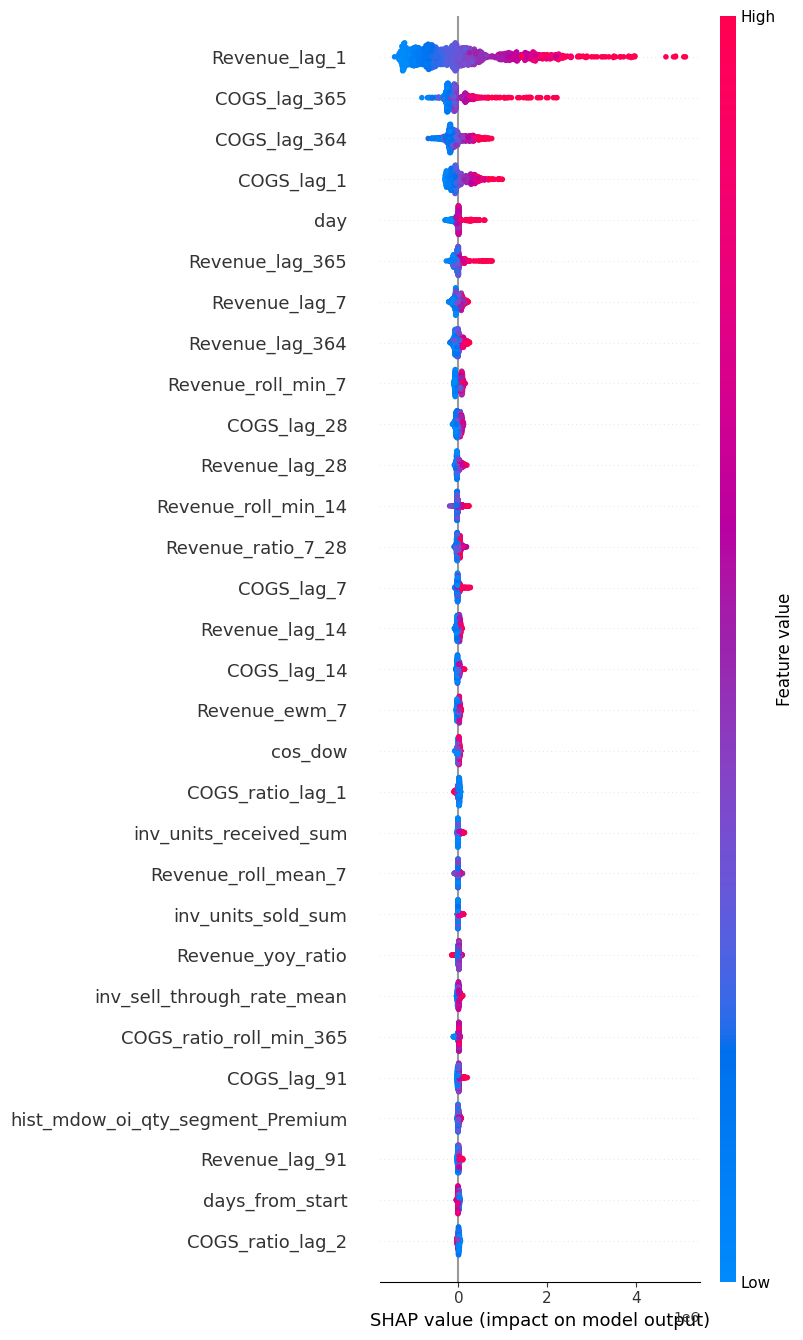

SHAP computed successfully. Uncomment shap.summary_plot to visualize.


In [ ]:
# Optional SHAP
try:
    import shap

    sample_X = X_full.sample(min(1000, len(X_full)), random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(model_revenue)
    shap_values = explainer.shap_values(sample_X)

    # Nếu chạy trong notebook interactive, bỏ comment dòng dưới:
    shap.summary_plot(shap_values, sample_X, max_display=30)

    print("SHAP computed successfully. Uncomment shap.summary_plot to visualize.")
except Exception as e:
    print("SHAP not available or failed:", e)
